# ***Programming for Data Analytics***
## **Muhammad Sameer (24169956)**
### **Dataset:** Career data_PDA_4053.xlsx
### **Target:** Data Cleaning & Exploratory Data Analysis (EDA)

* **Libraries**





In [ ]:
# imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

* **Loading Dataset - Career data_PDA_4053.xlsx**

In [ ]:
df = pd.read_excel("/content/Career data_PDA_4053.xlsx")
df.shape
df.head()
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Field of Study               4999 non-null   object 
 1   Current Occupation           4996 non-null   object 
 2   Age                          4996 non-null   float64
 3   Gender                       4993 non-null   object 
 4   Years of Experience          4998 non-null   float64
 5   Education Level              4994 non-null   object 
 6   Industry Growth Rate         4995 non-null   object 
 7   Job Satisfaction             4998 non-null   float64
 8   Work-Life Balance            4997 non-null   float64
 9   Job Opportunities            4993 non-null   float64
 10  Salary                       4994 non-null   object 
 11  Job Security                 4996 non-null   float64
 12  Career Change Interest       4995 non-null   object 
 13  Skills Gap        

,Field of Study,Current Occupation,Gender,Education Level,Industry Growth Rate,Salary,Career Change Interest,Certifications,Geographic Mobility
count,4999,4996,4993,4994,4995,4994,4995,4995,4996
unique,10,10,2,4,3,4930,3,3,3
top,Business,Software Developer,Female,High School,High,164940,0,0,0
freq,530,543,2536,1257,1693,3,4003,3479,3457


#### ***Check and correct data types***
* Salary is stored as object, but values are numeric
* Columns like Career Change Interest, Certifications, Geographic Mobility are stored as object and contain **0**, **1**, and an odd value **'A'**.
* Extracting **nan** values across the dataset

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\nColumn: {col}")
        print(df[col].unique())


Column: Field of Study
['Medicine' 'Education' 'Arts' 'Computer Science' 'Business'
 'Mechanical Engineering' 'Biology' 'Law' 'Economics' 'Psychology' nan]

Column: Current Occupation
['Business Analyst' 'Economist' 'Biologist' 'Doctor' 'Lawyer'
 'Software Developer' 'Artist' 'Psychologist' 'Teacher'
 'Mechanical Engineer' nan]

Column: Gender
['Male' 'Female' nan]

Column: Education Level
['High School' "Master's" 'PhD' "Bachelor's" nan]

Column: Industry Growth Rate
['High' 'Low' nan 'Medium']

Column: Salary
[198266 96803 65920 ... 115699 182137 158505]

Column: Career Change Interest
[0 1 nan 'A']

Column: Certifications
[0 1 nan 'A']

Column: Geographic Mobility
[1 0 nan 'A']


#### **Fix types:** Salary + binary fields

In [ ]:

df_raw = df.copy()

# Convert Salary to numeric
df_raw['Salary'] = pd.to_numeric(df_raw['Salary'], errors='coerce')

# Clean and convert binary-like columns
binary_obj_cols = ['Career Change Interest', 'Certifications', 'Geographic Mobility']

for col in binary_obj_cols:
    # Treat 'A' as invalid  -> set to NaN
    df_raw[col] = df_raw[col].replace('A', np.nan)
    # Convert to numeric (0/1)
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_raw = df_raw.dropna(subset=['Likely to Change Occupation'])
df_raw['Likely to Change Occupation'] = df_raw['Likely to Change Occupation'].astype(int)

df_raw.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Field of Study               4999 non-null   object 
 1   Current Occupation           4996 non-null   object 
 2   Age                          4996 non-null   float64
 3   Gender                       4993 non-null   object 
 4   Years of Experience          4998 non-null   float64
 5   Education Level              4994 non-null   object 
 6   Industry Growth Rate         4995 non-null   object 
 7   Job Satisfaction             4998 non-null   float64
 8   Work-Life Balance            4997 non-null   float64
 9   Job Opportunities            4993 non-null   float64
 10  Salary                       4993 non-null   float64
 11  Job Security                 4996 non-null   float64
 12  Career Change Interest       4994 non-null   float64
 13  Skills Gap             

/tmp/ipython-input-2938036370.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_raw[col] = df_raw[col].replace('A', np.nan)


### Initial statistical overview **(before preprocessing)**

In [ ]:
numeric_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_raw.select_dtypes(include=['object']).columns

df_raw[numeric_cols].describe()
df_raw[cat_cols].describe()
df_raw.isna().sum()

,0
Field of Study,0
Current Occupation,3
Age,3
Gender,6
Years of Experience,1
Education Level,5
Industry Growth Rate,4
Job Satisfaction,1
Work-Life Balance,2
Job Opportunities,6


### **Correlation before Preprocessing**

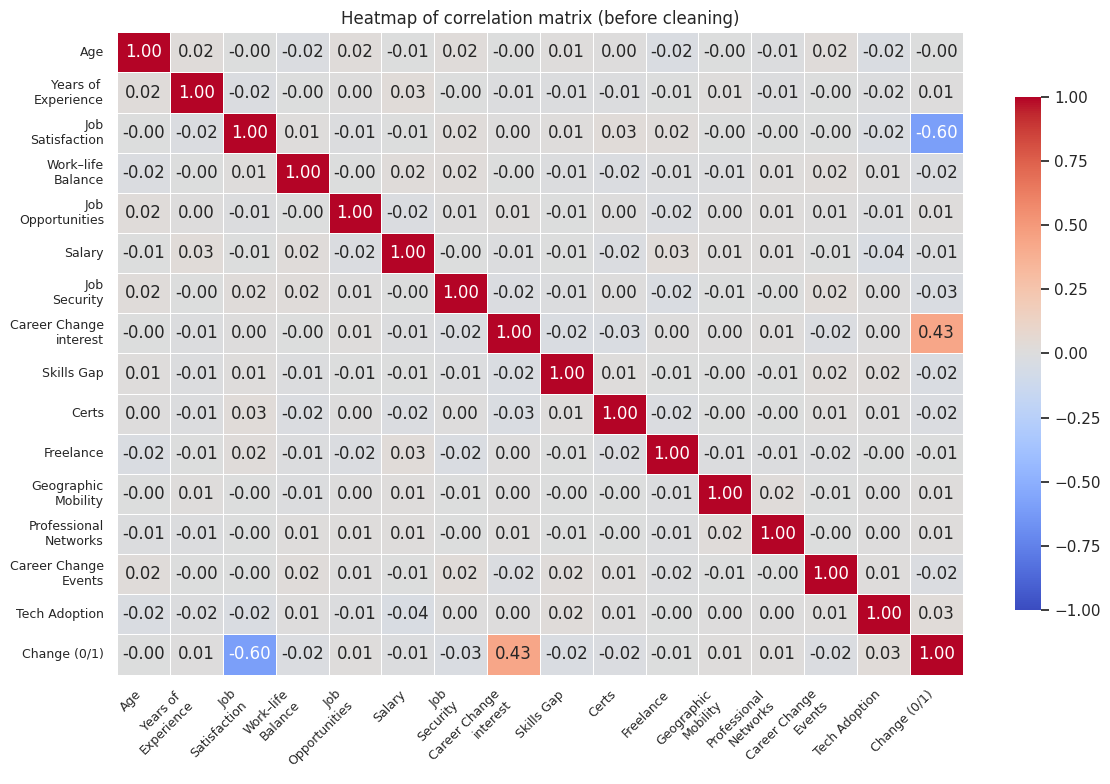

In [ ]:
plt.figure(figsize=(12, 8))

# Correlation on numeric columns
corr = df_raw[numeric_cols].corr()


label_map = {
    'Age': 'Age',
    'Years of Experience': 'Years of \nExperience',
    'Job Satisfaction': 'Job\nSatisfaction',
    'Work-Life Balance': 'Work–life\nBalance',
    'Job Opportunities': 'Job\nOpportunities',
    'Salary': 'Salary',
    'Job Security': 'Job\nSecurity',
    'Career Change Interest': 'Career Change\ninterest',
    'Skills Gap': 'Skills Gap',
    'Certifications': 'Certs',
    'Freelancing Experience': 'Freelance',
    'Geographic Mobility': 'Geographic\nMobility',
    'Professional Networks': 'Professional\nNetworks',
    'Career Change Events': 'Career Change\nEvents',
    'Technology Adoption': 'Tech Adoption',
    'Likely to Change Occupation': 'Change (0/1)'
}

corr_disp = corr.rename(index=label_map, columns=label_map)

# Heatmap
sns.heatmap(
    corr_disp,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap of correlation matrix (before cleaning)")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


### ***Handle missing values***
* **Numeric:** fill with median
* **Categorical:** fill with mode (most frequent category)

In [ ]:
df_clean = df_raw.copy()

# Numeric and categorical after type fixing
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_clean.select_dtypes(include=['object']).columns

# numeric
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# categorical
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean.isna().sum()

,0
Field of Study,0
Current Occupation,0
Age,0
Gender,0
Years of Experience,0
Education Level,0
Industry Growth Rate,0
Job Satisfaction,0
Work-Life Balance,0
Job Opportunities,0


### **Detect and handle outliers** (especially Salary)

* Visualise Salary before cleaning

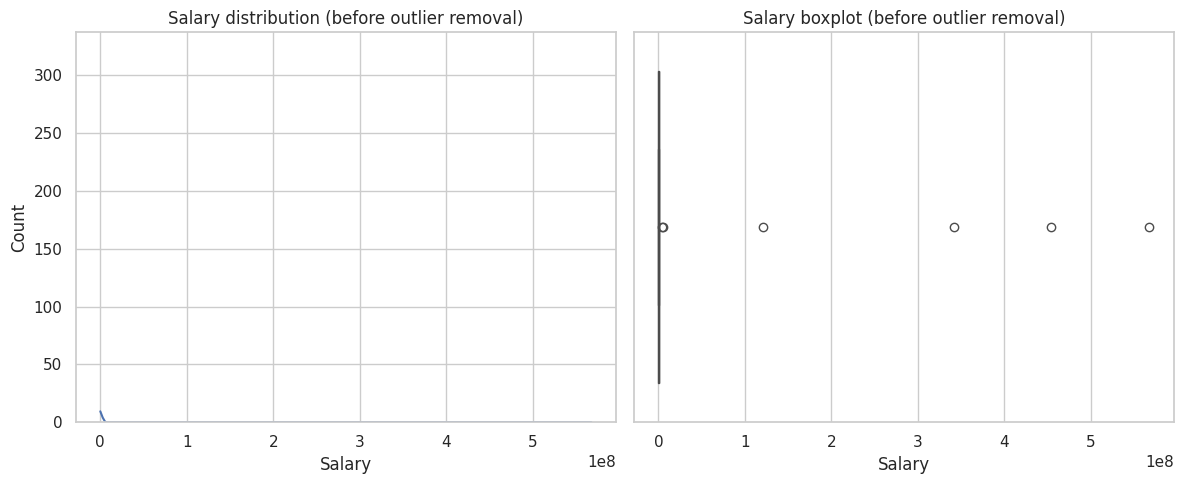

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_clean['Salary'], kde=True, ax=axes[0])
axes[0].set_title("Salary distribution (before outlier removal)")

sns.boxplot(x=df_clean['Salary'], ax=axes[1])
axes[1].set_title("Salary boxplot (before outlier removal)")

plt.tight_layout()
plt.show()

### Interquartile Range **(IQR)** method for Salary

In [ ]:
salary_q1 = df_clean['Salary'].quantile(0.25)
salary_q3 = df_clean['Salary'].quantile(0.75)
salary_iqr = salary_q3 - salary_q1

lower_bound = salary_q1 - 1.5 * salary_iqr
upper_bound = salary_q3 + 1.5 * salary_iqr

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df_clean[(df_clean['Salary'] < lower_bound) | (df_clean['Salary'] > upper_bound)]
print("Number of salary outliers:", outliers.shape[0])



Lower bound: -53446.75
Upper bound: 285167.25
Number of salary outliers: 6


### Removing outliers

In [ ]:
df_no_outliers = df_clean[
    (df_clean['Salary'] >= lower_bound) & (df_clean['Salary'] <= upper_bound)
].copy()

### Comparing Salary stats **(before vs after)**

In [ ]:
salary_before = df_clean['Salary']
salary_after = df_no_outliers['Salary']

print("Before:")
print(salary_before.describe())
print("Skewness:", salary_before.skew())

print("\nAfter:")
print(salary_after.describe())
print("Skewness:", salary_after.skew())


Before:
count    4.999000e+03
mean     4.149345e+05
std      1.149080e+07
min      3.001600e+04
25%      7.353350e+04
50%      1.164240e+05
75%      1.581870e+05
max      5.678965e+08
Name: Salary, dtype: float64
Skewness: 41.943130832777996

After:
count      4993.000000
mean     115867.425796
std       48869.073279
min       30016.000000
25%       73441.000000
50%      116424.000000
75%      158053.000000
max      199976.000000
Name: Salary, dtype: float64
Skewness: -0.023673297167260316


Visualising Salary **(Before vs After)**

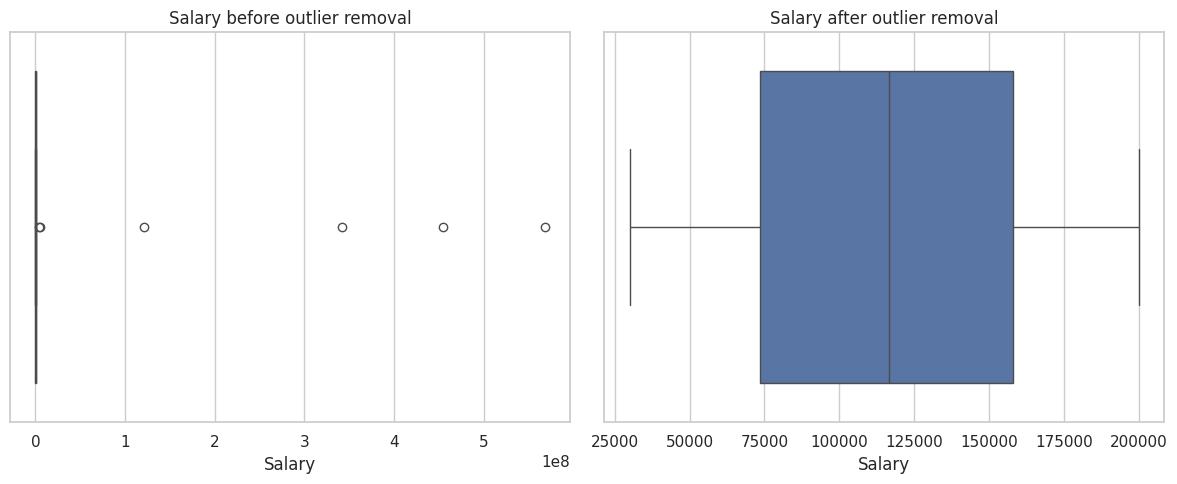

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=salary_before, ax=axes[0])
axes[0].set_title("Salary before outlier removal")

sns.boxplot(x=salary_after, ax=axes[1])
axes[1].set_title("Salary after outlier removal")

plt.tight_layout()
plt.show()


## **Exploratory Data Analysis (EDA) – before vs after**

In [ ]:
df_pre = df_clean          # After missing value handling, before salary outlier removal
df_final = df_no_outliers  # After both missing values and outlier handling

### Distributions of key numeric variables

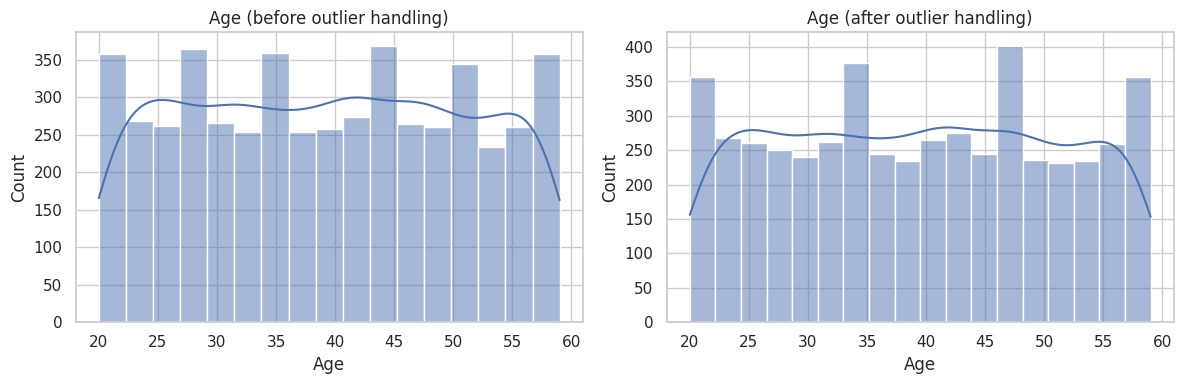

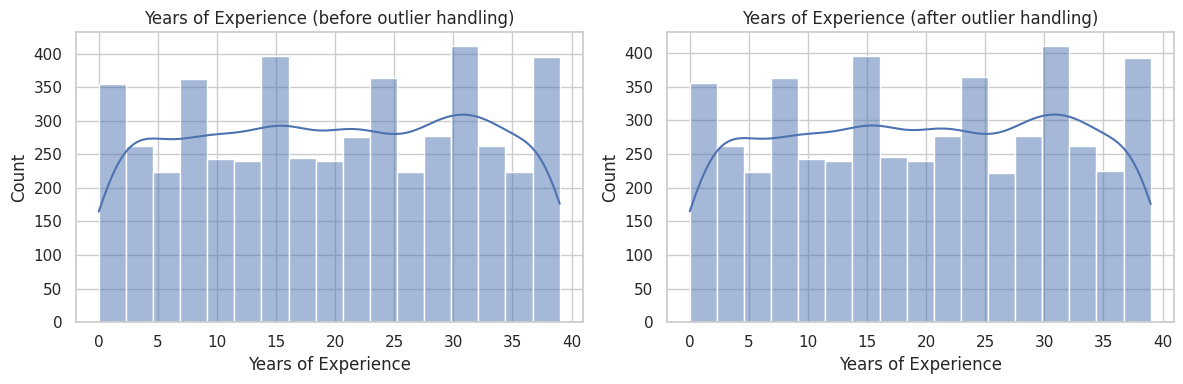

In [ ]:
for col in ['Age', 'Years of Experience']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_pre[col], kde=True, ax=axes[0])
    axes[0].set_title(f"{col} (before outlier handling)")

    sns.histplot(df_final[col], kde=True, ax=axes[1])
    axes[1].set_title(f"{col} (after outlier handling)")

    plt.tight_layout()
    plt.show()


### Distribution for **Salary (Before vs After)**

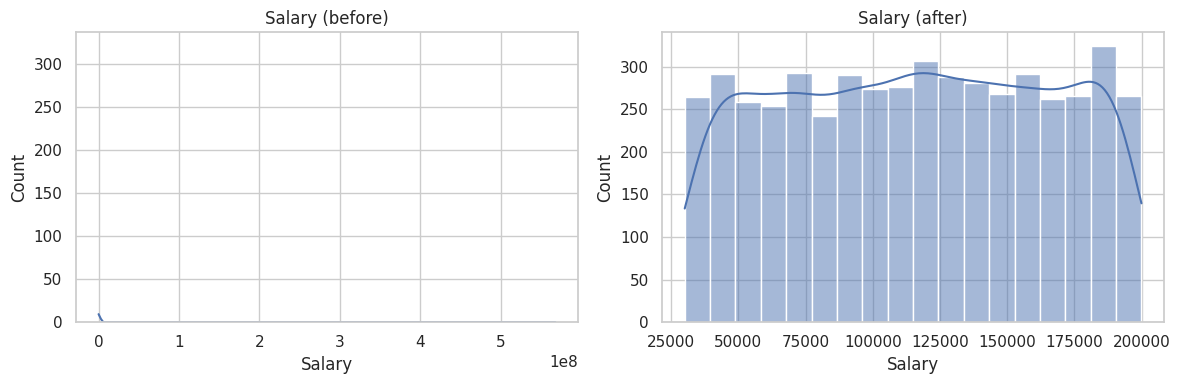

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_pre['Salary'], kde=True, ax=axes[0])
axes[0].set_title("Salary (before)")

sns.histplot(df_final['Salary'], kde=True, ax=axes[1])
axes[1].set_title("Salary (after)")

plt.tight_layout()
plt.show()

### **Target variable distribution**

/tmp/ipython-input-972607155.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


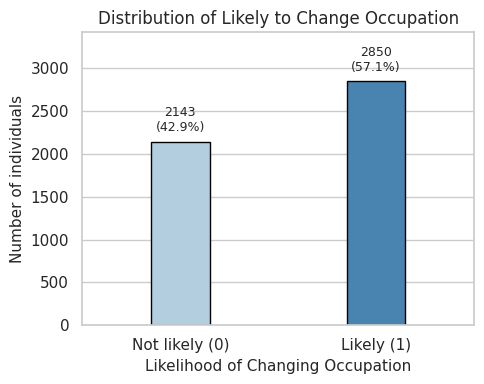

In [ ]:
sns.set_theme(style="whitegrid")

counts = df_final['Likely to Change Occupation'].value_counts().sort_index()
labels = ['Not likely (0)', 'Likely (1)']
total = counts.sum()
fig, ax = plt.subplots(figsize=(5, 4))

sns.barplot(
    x=labels,
    y=counts.values,
    palette="Blues",
    width=0.3,
    edgecolor="black",
    ax=ax
)

ax.set_title("Distribution of Likely to Change Occupation", fontsize=12)
ax.set_xlabel("Likelihood of Changing Occupation", fontsize=11)
ax.set_ylabel("Number of individuals", fontsize=11)

max_count = counts.max()
ax.set_ylim(0, max_count * 1.2)

for i, count in enumerate(counts.values):
    percent = 100 * count / total
    ax.text(
        i,
        count + max_count * 0.03,
        f"{count}\n({percent:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


## ***Relationship between categorical variables and target***

/tmp/ipython-input-2161734875.py:64: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.4, 0.2, 0.2, 0.2])


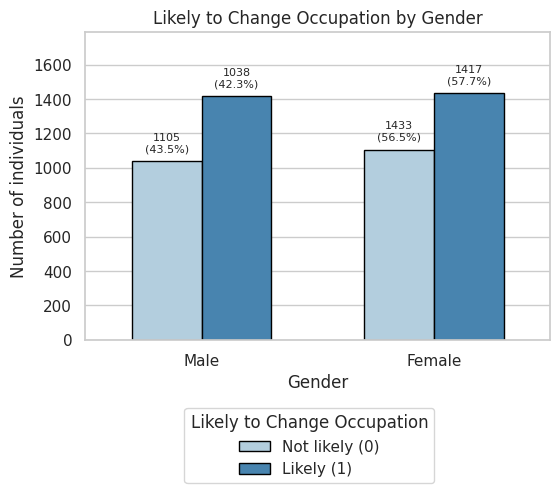

In [ ]:
sns.set_theme(style="whitegrid")

gender_stats = (
    df_final
    .groupby(['Gender', 'Likely to Change Occupation'])
    .size()
    .reset_index(name='count')
)

gender_stats['percent'] = (
    gender_stats['count'] /
    gender_stats.groupby('Gender')['count'].transform('sum') * 100
)

gender_order = ['Male', 'Female']
hue_order = [0, 1]

fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(
    data=gender_stats,
    x='Gender',
    y='count',
    hue='Likely to Change Occupation',
    order=gender_order,
    hue_order=hue_order,
    palette='Blues',
    edgecolor='black',
    width=0.6,
    ax=ax
)

ax.set_title("Likely to Change Occupation by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Number of individuals")

max_count = gender_stats['count'].max()
ax.set_ylim(0, max_count * 1.25)

# Add labels above bars
for p, (_, row) in zip(ax.patches, gender_stats.iterrows()):
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.text(
        x,
        y + max_count * 0.03,
        f"{int(row['count'])}\n({row['percent']:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=8
    )

# Legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['Not likely (0)', 'Likely (1)'],
    title='Likely to Change Occupation',
    loc='upper left',
    bbox_to_anchor=(0.2, -0.2),
    borderaxespad=0.4
)

plt.tight_layout(rect=[0.4, 0.2, 0.2, 0.2])
plt.show()


/tmp/ipython-input-1645720581.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0.1, 0.1, 0.8, 0.1])


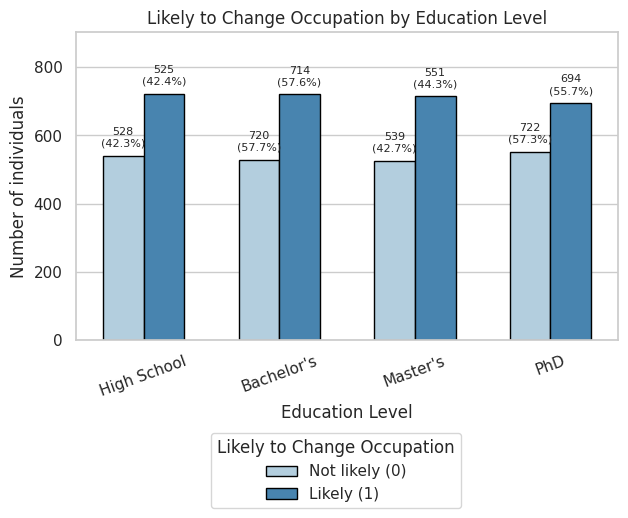

In [ ]:
sns.set_theme(style="whitegrid")

edu_stats = (
    df_final
    .groupby(['Education Level', 'Likely to Change Occupation'])
    .size()
    .reset_index(name='count')
)

edu_stats['percent'] = (
    edu_stats['count'] /
    edu_stats.groupby('Education Level')['count'].transform('sum') * 100
)

edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
hue_order = [0, 1]

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=edu_stats,
    x='Education Level',
    y='count',
    hue='Likely to Change Occupation',
    order=edu_order,
    hue_order=hue_order,
    palette='Blues',
    edgecolor='black',
    width=0.6,
    ax=ax
)

ax.set_title("Likely to Change Occupation by Education Level")
ax.set_xlabel("Education Level")
ax.set_ylabel("Number of individuals")
plt.xticks(rotation=20)

max_count = edu_stats['count'].max()
ax.set_ylim(0, max_count * 1.25)

for p, (_, row) in zip(ax.patches, edu_stats.iterrows()):
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.text(
        x,
        y + max_count * 0.03,
        f"{int(row['count'])}\n({row['percent']:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=8
    )

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['Not likely (0)', 'Likely (1)'],
    title='Likely to Change Occupation',
    loc='upper left',
    bbox_to_anchor=(0.25, -0.3),
    borderaxespad=0.
)

plt.tight_layout(rect=[0.1, 0.1, 0.8, 0.1])
plt.show()


### `Relationship between numeric variables and target`

In [ ]:
df_final.groupby('Likely to Change Occupation')[['Age', 'Years of Experience', 'Salary',
                                                 'Job Satisfaction', 'Work-Life Balance',
                                                 'Skills Gap', 'Career Change Events']].mean()

,Age,Years of Experience,Salary,Job Satisfaction,Work-Life Balance,Skills Gap,Career Change Events
Likely to Change Occupation,,,,,,,
0,39.358843,19.669155,125562.684554,7.496500,5.588427,5.619225,1.011666
1,39.376842,19.833684,108577.271579,3.994737,5.472632,5.478246,0.983860


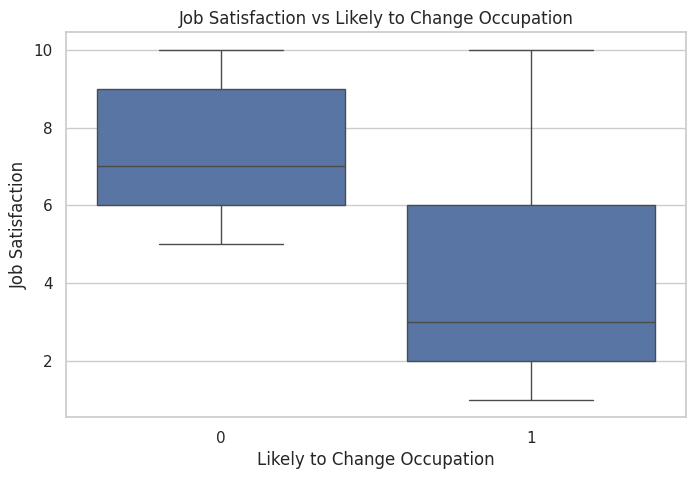

In [ ]:
sns.boxplot(
    x='Likely to Change Occupation',
    y='Job Satisfaction',
    data=df_final
)
plt.title("Job Satisfaction vs Likely to Change Occupation")
plt.show()

### Correlation matrix **(after cleaning)**

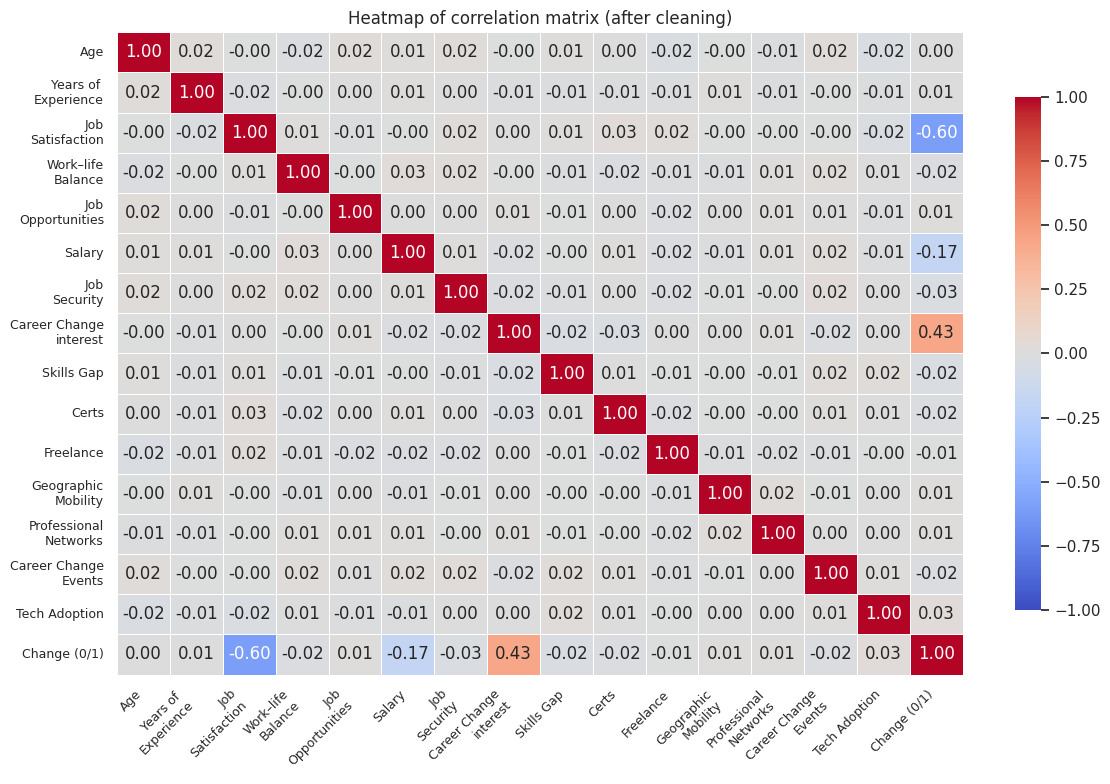

In [ ]:
# Numeric columns after cleaning
numeric_cols_final = df_final.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(12, 8))

# Correlation on numeric columns (after cleaning)
corr_final = df_final[numeric_cols_final].corr()

label_map = {
    'Age': 'Age',
    'Years of Experience': 'Years of \nExperience',
    'Job Satisfaction': 'Job\nSatisfaction',
    'Work-Life Balance': 'Work–life\nBalance',
    'Job Opportunities': 'Job\nOpportunities',
    'Salary': 'Salary',
    'Job Security': 'Job\nSecurity',
    'Career Change Interest': 'Career Change\ninterest',
    'Skills Gap': 'Skills Gap',
    'Certifications': 'Certs',
    'Freelancing Experience': 'Freelance',
    'Geographic Mobility': 'Geographic\nMobility',
    'Professional Networks': 'Professional\nNetworks',
    'Career Change Events': 'Career Change\nEvents',
    'Technology Adoption': 'Tech Adoption',
    'Likely to Change Occupation': 'Change (0/1)'
}

cols_for_map = [c for c in corr_final.columns if c in label_map]

corr_final = corr_final.loc[cols_for_map, cols_for_map]
corr_final_disp = corr_final.rename(index=label_map, columns=label_map)

# Heatmap (after cleaning)
sns.heatmap(
    corr_final_disp,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap of correlation matrix (after cleaning)")
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


### **Saving cleaned data**

In [ ]:
df_final.to_csv("career_data_cleaned.csv", index=False)